PULP Installation and its configuration

In [4]:
# --- Check and install PuLP if not present ---
try:
    import pulp
except ImportError:
    import sys, subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "pulp"])
    import pulp


print(pulp.listSolvers(onlyAvailable=True))



['PULP_CBC_CMD', 'HiGHS']


BIP Instance Generation

In [5]:
import numpy as np

def generate_random_BIP(num_vars=5, num_constraints=5, seed=None):
    """
    Generate a non-trivial Binary Integer Program (BIP):
        minimize   cᵀx
        subject to A x ≤ b
                   x ∈ {0,1}ⁿ

    Returns:
        c : np.ndarray of shape (num_vars,)
        A : np.ndarray of shape (num_constraints, num_vars)
        b : np.ndarray of shape (num_constraints,)
    """
    if seed is not None:
        np.random.seed(seed)

    # Positive objective coefficients → standard minimization
    c = np.random.randint(1, 10, size=num_vars)

    # Random positive coefficients for constraints
    A = np.random.randint(1, 10, size=(num_constraints, num_vars))

    # Ensure constraints are *tight enough* so that x=0 is NOT optimal
    # Strategy: pick random b values between ~30% and ~70% of total column sum
    b = (np.sum(A, axis=1) * np.random.uniform(0.3, 0.7, size=num_constraints)).astype(int)
    b = np.maximum(b, 1)  # prevent zeros

    return c, A, b


# Example usage:
c, A, b = generate_random_BIP(num_vars=5, num_constraints=5, seed=300)

print("Objective coefficients (c):", c)
print("\nConstraint matrix (A):\n", A)
print("\nRHS vector (b):", b)


Objective coefficients (c): [2 2 6 6 8]

Constraint matrix (A):
 [[7 7 3 4 4]
 [4 5 1 3 6]
 [4 2 8 5 7]
 [4 1 5 9 2]
 [6 8 8 8 3]]

RHS vector (b): [12 12 10  7 19]


Functions to (i) generate bound vectors ,(ii) solve BIP and declaration of important data structures

In [6]:
import matplotlib.pyplot as plt
from collections import defaultdict
from pulp import LpProblem, LpVariable, LpBinary, LpMinimize, lpSum
import itertools

# --- Generate valid vectors ---
def generate_valid_vectors(N):
    """Generate all 0/1 lists with the constraint: if vec[i] == 1, then vec[N+i] must be 1."""
    for vec in itertools.product([0, 1], repeat=2 * N):
        if all(not (vec[i] == 1 and vec[i + N] == 0) for i in range(N)):
            yield list(vec)  # convert tuple → mutable list



# --- Define your binary integer program ---
def solve_bip(vec, c, A, b):
    """
    Solve a binary integer program with bounds determined by vec.
    """
    N = len(c)
    model = LpProblem("BIP", LpMinimize)

    # Binary variables
    x = [LpVariable(f"x{i}", cat=LpBinary) for i in range(N)]

    # Apply lower/upper bounds from vec
    for i in range(N):
        x[i].lowBound = vec[i]
        x[i].upBound = vec[i + N]

    # Objective: minimize cᵀx
    model += lpSum(c[i] * x[i] for i in range(N))

    # Constraints: A x ≤ b
    for j in range(len(A)):
        model += lpSum(A[j][i] * x[i] for i in range(N)) <= b[j]

    # Solve
    model.solve(pulp.PULP_CBC_CMD(msg=False))

    return pulp.value(model.objective)


# --- Initialize global structures ---
Q = defaultdict(lambda: defaultdict(float))
v = defaultdict(float)
results = {}



Function to calculate Value Function corresponding to bound vectors

In [25]:
# --- Q-learning Value Function ---
def value_function(vec):
    """
    Update Q-values and value function v for a given state vector vec.
    vec: list of length 2*N representing current branching state.
    """
    N = len(vec) // 2
    vecL = vec.copy()
    vecR = vec.copy()

    diff_sum = 0.0  # <-- track average diff for plotting
    for i in range(N):
        # Left action: fix variable i to 0
        vecL[i] = 0
        vecL[i + N] = 0
        # Right action: fix variable i to 1
        vecR[i] = 1
        vecR[i + N] = 1

        # Compute Q-values
        diffL = abs(results.get(tuple(vec), 0.0) - results.get(tuple(vecL), 0.0))
        diffR = abs(results.get(tuple(vec), 0.0) - results.get(tuple(vecR), 0.0))

        diff_sum += (diffL + diffR) / 2.0  # average over both branches

        Q[tuple(vec)][(i, 'L')] = diffL + 0.99 * v.get(tuple(vecL), 0.0)
        Q[tuple(vec)][(i, 'R')] = diffR + 0.99 * v.get(tuple(vecR), 0.0)

    # Update value function v
    #v_delta = v[tuple(vec)]
    v[tuple(vec)] = max(Q[tuple(vec)].values(), default=0.0)
    #delta = max(delta,abs(v_delta - v[tuple(vec)]))
    # Return mean of average differences for this vec
    return v[tuple(vec)],diff_sum / N if N > 0 else 0.0
    #return diff_sum / N if N > 0 else 0.0


Value Function  Calculation and plotting the learning curve

Objective coefficients (c): [-10 -18 -12 -15 -12]

Constraint matrix (A):
 [[ 5 11  6  8  9]
 [ 6 19 13 12 13]
 [11 23 19 14 16]
 [ 0  0  0  1  1]
 [-1  1  0  0  0]]

RHS vector (b): [32 57 75  1  0]
Number of binary variables: 5


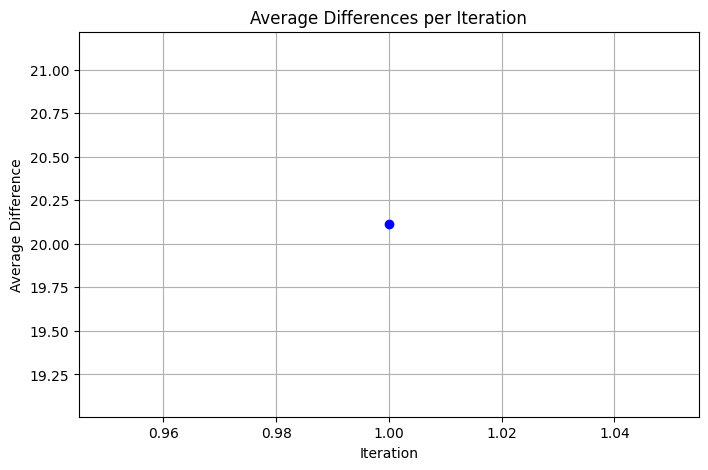


vec                 Value
------------------------------
(0, 0, 0, 0, 0, 0, 0, 0, 0, 0) 6699.999999999949
(0, 0, 0, 0, 0, 0, 0, 0, 0, 1) 6687.999999999949
(0, 0, 0, 0, 0, 0, 0, 0, 1, 0) 6684.999999999949
(0, 0, 0, 0, 0, 0, 0, 0, 1, 1) 6684.999999999949
(0, 0, 0, 0, 0, 0, 0, 1, 0, 0) 6687.999999999949
(0, 0, 0, 0, 0, 0, 0, 1, 0, 1) 6675.999999999949
(0, 0, 0, 0, 0, 0, 0, 1, 1, 0) 6672.999999999949
(0, 0, 0, 0, 0, 0, 0, 1, 1, 1) 6672.999999999949
(0, 0, 0, 0, 0, 0, 1, 0, 0, 0) 6699.999999999949
(0, 0, 0, 0, 0, 0, 1, 0, 0, 1) 6687.999999999949
(0, 0, 0, 0, 0, 0, 1, 0, 1, 0) 6684.999999999949
(0, 0, 0, 0, 0, 0, 1, 0, 1, 1) 6684.999999999949
(0, 0, 0, 0, 0, 0, 1, 1, 0, 0) 6687.999999999949
(0, 0, 0, 0, 0, 0, 1, 1, 0, 1) 6675.999999999949
(0, 0, 0, 0, 0, 0, 1, 1, 1, 0) 6672.999999999949
(0, 0, 0, 0, 0, 0, 1, 1, 1, 1) 6672.999999999949
(0, 0, 0, 0, 0, 1, 0, 0, 0, 0) 6689.999999999949
(0, 0, 0, 0, 0, 1, 0, 0, 0, 1) 6677.999999999949
(0, 0, 0, 0, 0, 1, 0, 0, 1, 0) 6674.999999999949
(0, 0, 0, 0

In [28]:
import numpy as np
theta = 0.001
#delta = float('inf')
v_delta = 0
# --- Define a small test instance ---
N = 5
#c, A, b = generate_random_BIP(num_vars=5, num_constraints=5, seed=300)

# Objective function coefficients (minimize -profit)
c = np.array([-10, -18, -12, -15, -12])

# Inequality constraint matrix (A_ub @ x <= b_ub)
A = np.array([
    [5, 11, 6, 8, 9],
    [6, 19, 13, 12, 13],
    [11, 23, 19, 14, 16],
    [0, 0, 0, 1, 1],
    [-1, 1, 0, 0, 0]
])

# Right-hand side of inequality constraints
b = np.array([32, 57, 75, 1, 0])


print("Objective coefficients (c):", c)
print("\nConstraint matrix (A):\n", A)
print("\nRHS vector (b):", b)

print("Number of binary variables:", N)

# --- Main Learning Loop ---
avg_diffs = []

while True:
    vec_diffs = []
    delta = 0
    for vec in generate_valid_vectors(N):
        obj_val = solve_bip(vec, c, A, b)
        results[tuple(vec)] = obj_val
        v_delta = v[tuple(vec)]
        vec_val,avg_diff_vec = value_function(vec)
        vec_diffs.append(avg_diff_vec)
        v[tuple(vec)] = max(Q[tuple(vec)].values(), default=0.0)
        delta = max(delta,abs(v_delta - vec_val))
        

    # Mean of all vec differences for this episode
    avg_diffs.append(sum(vec_diffs) / len(vec_diffs))
    if (delta < theta):
        break



# Assuming avg_diffs is your list of averages
iterations = range(1, len(avg_diffs) + 1)

plt.figure(figsize=(8, 5))
plt.plot(iterations, avg_diffs, marker='o', linestyle='-', color='blue')
plt.title('Average Differences per Iteration')
plt.xlabel('Iteration')
plt.ylabel('Average Difference')
plt.grid(True)
plt.show()




# --- Print Final Value Function ---
print("\nvec".ljust(20), "Value")
print("-" * 30)
for vec, value in v.items():
    print(f"{str(vec).ljust(20)} {value}")


Objective coefficients (c): [-10 -18 -12 -15 -12]

Constraint matrix (A):
 [[ 5 11  6  8  9]
 [ 6 19 13 12 13]
 [11 23 19 14 16]
 [ 0  0  0  1  1]
 [-1  1  0  0  0]]

RHS vector (b): [32 57 75  1  0]
Number of binary variables: 5


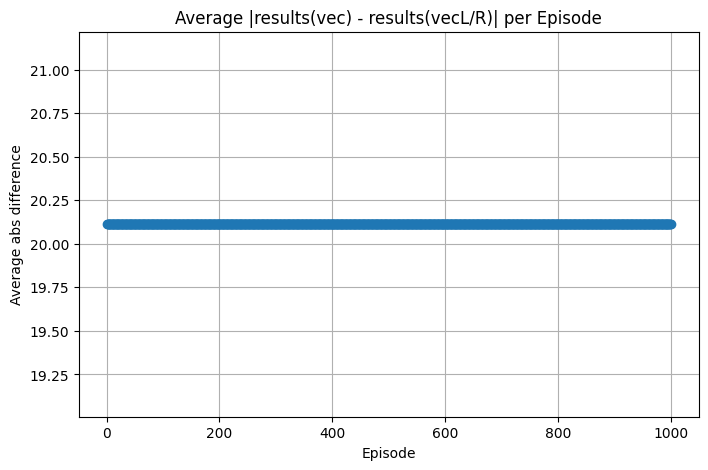


vec                 Value
------------------------------
(0, 0, 0, 0, 0, 0, 0, 0, 0, 0) 6699.999999999949
(0, 0, 0, 0, 0, 0, 0, 0, 0, 1) 6687.999999999949
(0, 0, 0, 0, 0, 0, 0, 0, 1, 0) 6684.999999999949
(0, 0, 0, 0, 0, 0, 0, 0, 1, 1) 6684.999999999949
(0, 0, 0, 0, 0, 0, 0, 1, 0, 0) 6687.999999999949
(0, 0, 0, 0, 0, 0, 0, 1, 0, 1) 6675.999999999949
(0, 0, 0, 0, 0, 0, 0, 1, 1, 0) 6672.999999999949
(0, 0, 0, 0, 0, 0, 0, 1, 1, 1) 6672.999999999949
(0, 0, 0, 0, 0, 0, 1, 0, 0, 0) 6699.999999999949
(0, 0, 0, 0, 0, 0, 1, 0, 0, 1) 6687.999999999949
(0, 0, 0, 0, 0, 0, 1, 0, 1, 0) 6684.999999999949
(0, 0, 0, 0, 0, 0, 1, 0, 1, 1) 6684.999999999949
(0, 0, 0, 0, 0, 0, 1, 1, 0, 0) 6687.999999999949
(0, 0, 0, 0, 0, 0, 1, 1, 0, 1) 6675.999999999949
(0, 0, 0, 0, 0, 0, 1, 1, 1, 0) 6672.999999999949
(0, 0, 0, 0, 0, 0, 1, 1, 1, 1) 6672.999999999949
(0, 0, 0, 0, 0, 1, 0, 0, 0, 0) 6689.999999999949
(0, 0, 0, 0, 0, 1, 0, 0, 0, 1) 6677.999999999949
(0, 0, 0, 0, 0, 1, 0, 0, 1, 0) 6674.999999999949
(0, 0, 0, 0

In [15]:
import numpy as np
# --- Define a small test instance ---
N = 5
#c, A, b = generate_random_BIP(num_vars=5, num_constraints=5, seed=300)

# Objective function coefficients (minimize -profit)
c = np.array([-10, -18, -12, -15, -12])

# Inequality constraint matrix (A_ub @ x <= b_ub)
A = np.array([
    [5, 11, 6, 8, 9],
    [6, 19, 13, 12, 13],
    [11, 23, 19, 14, 16],
    [0, 0, 0, 1, 1],
    [-1, 1, 0, 0, 0]
])

# Right-hand side of inequality constraints
b = np.array([32, 57, 75, 1, 0])


print("Objective coefficients (c):", c)
print("\nConstraint matrix (A):\n", A)
print("\nRHS vector (b):", b)

print("Number of binary variables:", N)

# --- Main Learning Loop ---
avg_diffs_per_episode = []

for episode in range(1000):
    vec_diffs = []

    for vec in generate_valid_vectors(N):
        obj_val = solve_bip(vec, c, A, b)
        results[tuple(vec)] = obj_val

        avg_diff_vec = value_function(vec)
        vec_diffs.append(avg_diff_vec)

    # Mean of all vec differences for this episode
    avg_diffs_per_episode.append(sum(vec_diffs) / len(vec_diffs))

# --- Plot ---
plt.figure(figsize=(8,5))
plt.plot(range(1, 1001), avg_diffs_per_episode, marker='o', linewidth=2)
plt.xlabel("Episode")
plt.ylabel("Average abs difference")
plt.title("Average |results(vec) - results(vecL/R)| per Episode")
plt.grid(True)
plt.show()



# --- Print Final Value Function ---
print("\nvec".ljust(20), "Value")
print("-" * 30)
for vec, value in v.items():
    print(f"{str(vec).ljust(20)} {value}")


Extracting optimal branching decisions and node selection decision (POLICY)

In [29]:
# --- Post-Learning Argmax Extraction ---
final_argmax = {}
for vec, actions in Q.items():
    if actions:
        best_action = max(actions, key=actions.get)
        final_argmax[vec] = best_action
    else:
        final_argmax[vec] = None

# --- Print Results ---
print("\nFinal Value Function and Best Actions:")
print("vec".ljust(25), "Value".ljust(10), "Best Action")
print("-" * 55)
for vec, best_action in final_argmax.items():
    best_val = Q[vec][best_action] if best_action else 0.0
    print(f"{str(vec).ljust(25)} {str(round(best_val, 4)).ljust(10)} {best_action}")


Final Value Function and Best Actions:
vec                       Value      Best Action
-------------------------------------------------------
(0, 0, 0, 0, 0, 0, 0, 0, 0, 0) 6700.0     (4, 'R')
(0, 0, 0, 0, 0, 0, 0, 0, 0, 1) 6688.0     (4, 'R')
(0, 0, 0, 0, 0, 0, 0, 0, 1, 0) 6685.0     (4, 'R')
(0, 0, 0, 0, 0, 0, 0, 0, 1, 1) 6685.0     (4, 'R')
(0, 0, 0, 0, 0, 0, 0, 1, 0, 0) 6688.0     (4, 'R')
(0, 0, 0, 0, 0, 0, 0, 1, 0, 1) 6676.0     (4, 'R')
(0, 0, 0, 0, 0, 0, 0, 1, 1, 0) 6673.0     (4, 'R')
(0, 0, 0, 0, 0, 0, 0, 1, 1, 1) 6673.0     (4, 'R')
(0, 0, 0, 0, 0, 0, 1, 0, 0, 0) 6700.0     (4, 'R')
(0, 0, 0, 0, 0, 0, 1, 0, 0, 1) 6688.0     (4, 'R')
(0, 0, 0, 0, 0, 0, 1, 0, 1, 0) 6685.0     (4, 'R')
(0, 0, 0, 0, 0, 0, 1, 0, 1, 1) 6685.0     (4, 'R')
(0, 0, 0, 0, 0, 0, 1, 1, 0, 0) 6688.0     (4, 'R')
(0, 0, 0, 0, 0, 0, 1, 1, 0, 1) 6676.0     (4, 'R')
(0, 0, 0, 0, 0, 0, 1, 1, 1, 0) 6673.0     (4, 'R')
(0, 0, 0, 0, 0, 0, 1, 1, 1, 1) 6673.0     (4, 'R')
(0, 0, 0, 0, 0, 1, 0, 0, 0, 0) 6690.0  

OPTIMAL SOLUTION OF THE PROBLEM

In [30]:
import numpy as np
# Objective function coefficients (minimize -profit)
c = np.array([-10, -18, -12, -15, -12])

# Inequality constraint matrix (A_ub @ x <= b_ub)
A = np.array([
    [5, 11, 6, 8, 9],
    [6, 19, 13, 12, 13],
    [11, 23, 19, 14, 16],
    [0, 0, 0, 1, 1],
    [-1, 1, 0, 0, 0]
])

# Right-hand side of inequality constraints
b = np.array([32, 57, 75, 1, 0])


#c, A, b = generate_random_BIP(num_vars=5, num_constraints=5, seed=300)

print("Objective coefficients (c):", c)
print("\nConstraint matrix (A):\n", A)
print("\nRHS vector (b):", b)

N = len(c)
model = LpProblem("BIP", pulp.LpMinimize)

    # Binary variables
x = [LpVariable(f"x{i}", cat=LpBinary) for i in range(N)]



    # Objective: minimize cᵀx
model += lpSum(c[i] * x[i] for i in range(N))

    # Constraints: A x ≤ b
for j in range(len(A)):
    model += lpSum(A[j][i] * x[i] for i in range(N)) <= b[j]

    # Solve
model.solve(pulp.PULP_CBC_CMD(msg=False))

print(f"\nOptimal Value of the original Problem = {pulp.value(model.objective)}")
solution = {var.name: var.value() for var in model.variables()}
Optimal_Objective = pulp.value(model.objective)
Optimal_Solution = list(solution)
print(solution)



Objective coefficients (c): [-10 -18 -12 -15 -12]

Constraint matrix (A):
 [[ 5 11  6  8  9]
 [ 6 19 13 12 13]
 [11 23 19 14 16]
 [ 0  0  0  1  1]
 [-1  1  0  0  0]]

RHS vector (b): [32 57 75  1  0]

Optimal Value of the original Problem = -55.0
{'x0': 1.0, 'x1': 1.0, 'x2': 1.0, 'x3': 1.0, 'x4': 0.0}


Using the policy learnt to reach optimality/infeasibility

In [31]:
def solve_bip_policy(vec, c, A, b):
    """
    Solve a binary integer program with bounds determined by policy.
    """
    N = len(c)
    action = final_argmax.get(tuple(vec))
    index, direction = action
    prob = LpProblem("BIP", LpMinimize)
    

    # Binary variables
    x = [LpVariable(f"x{i}", cat=LpBinary) for i in range(N)]

    prev_vec = vec.copy()
    
    for i in range(N):
        if i == index:
            continue
        x[i].lowBound = vec[i]
        x[i].upBound = vec[i + N]



    # Apply lower/upper bounds from action
    if direction == "L":
        x[index].lowBound = 0
        x[index].upBound = 0
        vec[index] = 0
        vec[index + N] = 0
    elif direction == "R":
        x[index].lowBound = 1
        x[index].upBound = 1
        vec[index] = 1
        vec[index + N] = 1
    
    
    # Objective: minimize cᵀx
    prob += lpSum(c[i] * x[i] for i in range(N))

    # Constraints: A x ≤ b
    for j in range(len(A)):
        prob += lpSum(A[j][i] * x[i] for i in range(N)) <= b[j]

    # Solve
    #status = prob.solve(pulp.HiGHS_CMD(msg=False))
    status = prob.solve(pulp.PULP_CBC_CMD(msg=False))
    action = final_argmax.get(tuple(vec))
    print(f"Current State :{str(vec).ljust(25)} {action}")
    
    print(f"\nValue at Current State = {pulp.value(prob.objective)}")
    solution = {var.name: var.value() for var in prob.variables()}
    print(f"Solution at Current State", solution)
    if Optimal_Objective == pulp.value(prob.objective) and Optimal_Solution == list({var.name: var.value() for var in prob.variables()}):
        status_str = 'Optimal'
        print("Optimal State:", vec)
        print("\nObjective:", pulp.value(prob.objective))
        for v in prob.variables():
            print(f"{v.name} = {v.varValue}")
    
    elif pulp.LpStatus[status] == 'Infeasible':
        status_str = 'Infeasible'
    else:
        status_str = 'Unrolling'
    

    

       
   
    
    return status_str





In [ ]:
import random
#c, A, b = generate_random_BIP(num_vars=5, num_constraints=5, seed=300)
# Objective function coefficients (minimize -profit)
c = np.array([-10, -18, -12, -15, -12])

# Inequality constraint matrix (A_ub @ x <= b_ub)
A = np.array([
    [5, 11, 6, 8, 9],
    [6, 19, 13, 12, 13],
    [11, 23, 19, 14, 16],
    [0, 0, 0, 1, 1],
    [-1, 1, 0, 0, 0]
])

# Right-hand side of inequality constraints
b = np.array([32, 57, 75, 1, 0])


print("Objective coefficients (c):", c)
print("\nConstraint matrix (A):\n", A)
print("\nRHS vector (b):", b)
N = len(c)
valid_vectors = list(generate_valid_vectors(N))
vec = random.choice(valid_vectors)
action = final_argmax.get(tuple(vec))
#vec = [0]*N + [1]*N
print(f"Initial State :{str(vec).ljust(25)} {action}")
while True:
    # Solve your problem
    status_str = solve_bip_policy(vec, c, A, b)

    if status_str in ['Optimal','Infeasible']:
        print(f"Stopping: {status_str}")
        break  # exit the loop
    else:
        print(f"Solver returned {status_str}, retrying...")
        # Optional: do something before retrying, e.g., change parameters

    


Objective coefficients (c): [-10 -18 -12 -15 -12]

Constraint matrix (A):
 [[ 5 11  6  8  9]
 [ 6 19 13 12 13]
 [11 23 19 14 16]
 [ 0  0  0  1  1]
 [-1  1  0  0  0]]

RHS vector (b): [32 57 75  1  0]
Initial State :[0, 0, 0, 0, 1, 1, 1, 1, 0, 1] (4, 'L')
Current State :[0, 0, 0, 0, 0, 1, 1, 1, 0, 0] (2, 'L')

Value at Current State = -40.0
Solution at Current State {'x0': 1.0, 'x1': 1.0, 'x2': 1.0, 'x3': 0.0, 'x4': 0.0}
Solver returned Unrolling, retrying...
Current State :[0, 0, 0, 0, 0, 1, 1, 0, 0, 0] (4, 'R')

Value at Current State = -28.0
Solution at Current State {'x0': 1.0, 'x1': 1.0, 'x2': 0.0, 'x3': 0.0, 'x4': 0.0}
Solver returned Unrolling, retrying...
Current State :[0, 0, 0, 0, 1, 1, 1, 0, 0, 1] (4, 'L')

Value at Current State = -40.0
Solution at Current State {'x0': 1.0, 'x1': 1.0, 'x2': 0.0, 'x3': 0.0, 'x4': 1.0}
Solver returned Unrolling, retrying...
Current State :[0, 0, 0, 0, 0, 1, 1, 0, 0, 0] (4, 'R')

Value at Current State = -28.0
Solution at Current State {'x0': 1

Traceback (most recent call last):
  File "/home/kkishan/MCL261 Assignment/.venv/lib/python3.12/site-packages/IPython/core/interactiveshell.py", line 3699, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "/tmp/ipykernel_325229/4018922348.py", line 30, in <module>
    status_str = solve_bip_policy(vec, c, A, b)
                 ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/tmp/ipykernel_325229/1243053197.py", line 46, in solve_bip_policy
    status = prob.solve(pulp.PULP_CBC_CMD(msg=False))
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/kkishan/MCL261 Assignment/.venv/lib/python3.12/site-packages/pulp/pulp.py", line 2092, in solve
    status = solver.actualSolve(self, **kwargs)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/kkishan/MCL261 Assignment/.venv/lib/python3.12/site-packages/pulp/apis/coin_api.py", line 144, in actualSolve
    return self.solve_CBC(lp, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/kkishan/